In [10]:
import os, ee, geemap, geopandas as gpd, pandas as pd
ee.Initialize()

# ---------- 1. Load Lahore UCs safely ----------
def load_ucs_to_ee(shp_path):
    gdf = gpd.read_file(shp_path)
    if gdf.crs is None or gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(4326)
    gdf["geometry"] = gdf["geometry"].buffer(0)
    ucs = geemap.gdf_to_ee(gdf)
    return ucs, "UC", ucs.geometry()

ucs, id_field, region = load_ucs_to_ee("../../data/Lahore UCs/Lahore UC.shp")

# ---------- 2. Build monthly Landsat 8/9 LST composite ----------
START, END = "2024-10-01", "2024-10-31"
COLS = ["LANDSAT/LC08/C02/T1_L2", "LANDSAT/LC09/C02/T1_L2"]

def _mask_l2(img):
    qa = img.select("QA_PIXEL")
    mask = qa.bitwiseAnd(1 << 3).eq(0)\
          .And(qa.bitwiseAnd(1 << 4).eq(0))\
          .And(qa.bitwiseAnd(1 << 5).eq(0))\
          .And(qa.bitwiseAnd(1 << 7).eq(0))
    return img.updateMask(mask)

def _st_to_c(img):
    st = img.select("ST_B10")
    st = st.multiply(0.00341802).add(149.0)   # apply scale + offset
    st_c = st.subtract(273.15).rename("LST_C")
    return img.addBands(st_c, overwrite=True)

def _prep(img):
    return _st_to_c(_mask_l2(img)).select("LST_C").clip(region)

col = (ee.ImageCollection(COLS[0])
       .merge(ee.ImageCollection(COLS[1]))
       .filterBounds(region)
       .filterDate(START, END)
       .map(_prep))

lst_c_med = col.median().rename("LST_C")
lst_c_vis = lst_c_med.resample('bilinear').reproject(crs='EPSG:4326', scale=100)

# --- 3b. Robust visualization stretch from data percentiles ---
p = lst_c_med.reduceRegion(
    reducer=ee.Reducer.percentile([5, 95]),
    geometry=region,
    scale=100,
    maxPixels=1e13,
    bestEffort=True
)
p5  = p.getNumber('LST_C_p5')
p95 = p.getNumber('LST_C_p95')

vis = {
    "min": p5.getInfo() if p5 else 20,
    "max": p95.getInfo() if p95 else 45,
    "palette": ["040274","2c7bb6","abd9e9","ffffbf","fdae61","d7191c"]
}

# --- 3c. Show interactively (ipyleaflet backend) ---
m = geemap.Map(center=[31.5204, 74.3587], zoom=10)
m.addLayer(lst_c_vis, vis, "Landsat LST (°C) — Oct 2024")
m.addLayer(ucs.style(color="black", fillColor="00000000", width=1), {}, "UC boundaries")
m.to_html("lahore_lst_map.html")  # interactive HTML snapshot
print("[OK] Saved interactive map → lahore_lst_map.html")

# ---------- 4. Export local files (version-agnostic) ----------
def export_image_local(img, filename, region, scale=100, crs='EPSG:4326'):
    """
    Robust Earth Engine → local GeoTIFF export.
    Tries: geemap.ee_export_image (positional args),
           geemap.download_ee_image,
           then EE direct download URL.
    """
    # 4A) geemap.ee_export_image (positional args only)
    try:
        geemap.ee_export_image(img.clip(region), filename, scale=scale, region=region, file_per_band=False)
        print(f"[OK] Exported raster via geemap.ee_export_image → {filename}")
        return
    except TypeError:
        # wrong signature in this geemap version, try next
        pass
    except Exception as e:
        print("[INFO] ee_export_image failed:", e)

    # 4B) geemap.download_ee_image (works in many versions)
    try:
        geemap.download_ee_image(img.clip(region), filename=filename, scale=scale, region=region, crs=crs)
        print(f"[OK] Exported raster via geemap.download_ee_image → {filename}")
        return
    except Exception as e:
        print("[INFO] download_ee_image failed:", e)

    # 4C) Raw EE URL download (last resort)
    try:
        url = img.clip(region).getDownloadURL({
            "scale": scale,
            "crs": crs,
            "region": region,
            "filePerBand": False
        })
        import urllib.request
        urllib.request.urlretrieve(url, filename)
        print(f"[OK] Exported raster via EE getDownloadURL → {filename}")
        return
    except Exception as e:
        raise RuntimeError(f"All export methods failed: {e}")

# (A) Export GeoTIFF raster (100 m)
out_tif = "LST_Lahore_Oct2024_100m.tif"
export_image_local(lst_c_med, out_tif, region, scale=100, crs='EPSG:4326')

# (B) UC-wise average LST (°C) → CSV
uc_stats = lst_c_med.reduceRegions(
    collection=ucs,
    reducer=ee.Reducer.mean(),
    scale=100,
    tileScale=2
)

def fc_to_df(fc):
    # prefer geemap.ee_to_df; fallback to getInfo
    try:
        return geemap.ee_to_df(fc)
    except Exception:
        info = ee.FeatureCollection(fc).getInfo()
        rows = [f["properties"] for f in info.get("features", [])]
        import pandas as pd
        return pd.DataFrame(rows)

df_uc = fc_to_df(uc_stats).rename(columns={"mean": "LST_C_mean"})
df_uc.to_csv("LST_Lahore_UC_stats.csv", index=False)
print("[OK] Saved UC stats → LST_Lahore_UC_stats.csv")
print(df_uc.head(3))



[OK] Saved interactive map → lahore_lst_map.html
Generating URL ...
Please wait ...
Data downloaded to /Users/ahmed/Desktop/Senior Fall 25/SPROJ - Dr Tahir/SPROJ/notebooks/Landsat/LST_Lahore_Oct2024_100m.tif
[OK] Exported raster via geemap.ee_export_image → LST_Lahore_Oct2024_100m.tif
[OK] Saved UC stats → LST_Lahore_UC_stats.csv
   Area DISTRICT  DISTRICT_C Data_Sourc         Flood PROVINCE  PROVINCE_C  \
0     0    Kasur           0    Alhasan  KOT RADHA KI   Punjab           6   
1     0    Kasur           0    Alhasan  SARHAI KALAN   Punjab           6   
2     0    Kasur           0    Alhasan         MEHTA   Punjab           6   

   School  Shape_Area  Shape_Leng TEHSIL  TEHSIL_C            UC  UC_C  fid  \
0       0    0.003003    0.214334  Kasur         0  Kot Radha Ki     0    1   
1       0    0.005790    0.322514  Kasur         0  Sarhai Kalan     0    2   
2       0    0.004347    0.346153  Kasur         0         Mehta     0    3   

   LST_C_mean Level  
0   32.896523   

## 🟩 (1) UC-average choropleth

In [13]:
import folium, geopandas as gpd, pandas as pd

# Load shapefile and join the UC means
gdf_uc = gpd.read_file("../../data/Lahore UCs/Lahore UC.shp")
df_mean = pd.read_csv("LST_Lahore_UC_stats.csv")

id_field = "UC"  # or the column that matches in both files
gdf = gdf_uc.merge(df_mean[[id_field, "LST_C_mean"]], on=id_field, how="left")

m_uc = folium.Map(location=[31.5204, 74.3587],
                  zoom_start=10, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=gdf,
    data=gdf[[id_field, "LST_C_mean"]],
    columns=[id_field, "LST_C_mean"],
    key_on=f"feature.properties.{id_field}",
    fill_color="YlOrRd",
    fill_opacity=0.85,
    line_opacity=0.5,
    legend_name="Mean LST (°C)",
).add_to(m_uc)

folium.LayerControl(collapsed=False).add_to(m_uc)
m_uc.save("lahore_uc_heatmap.html")
m_uc


In [3]:

import folium, leafmap

# Path to your exported raster
tif_path = "LST_Lahore_Oct2024_100m.tif"

# Color ramp similar to your GEE vis
palette = ["040274","2c7bb6","abd9e9","ffffbf","fdae61","d7191c"]

# Create folium map
m_raster = leafmap.Map(center=[31.5204, 74.3587], zoom=10, tiles="cartodbpositron")

# Add the raster overlay
m_raster.add_raster(
    tif_path,
    colormap=palette,
    vmin=20,
    vmax=45,
    layer_name="LST (°C)",
    opacity=0.8,
)

# Add UC boundaries (optional)
import geopandas as gpd
ucs = gpd.read_file("../../data/Lahore UCs/Lahore UC.shp").to_crs(4326)
m_raster.add_gdf(ucs, layer_name="UC boundaries", style={"color": "black", "fillOpacity": 0})

# Save to html
m_raster.save("lahore_lst_raster_heatmap.html")
m_raster


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 18.8 MB 99 kB/s eta 0:00:013
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


ImportError: localtileserver is not installed. Please install it before proceeding. https://github.com/banesullivan/localtileserver


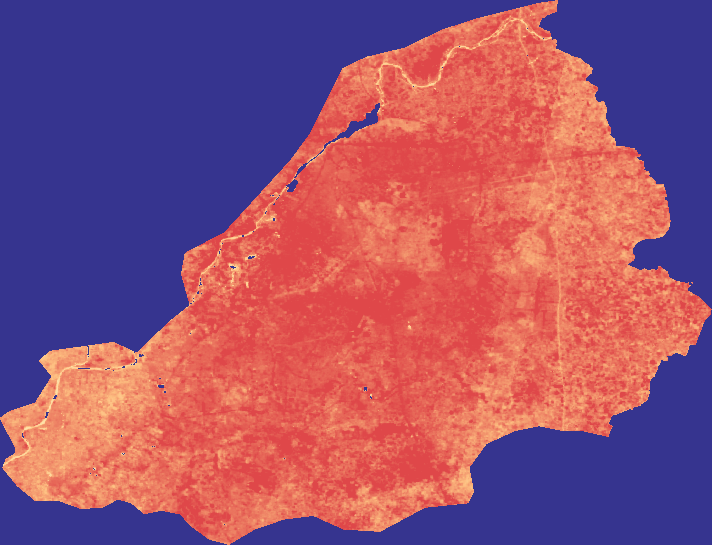

In [4]:
# --- Convert GeoTIFF -> colorized PNG and overlay in Folium (no localtileserver needed)
import rasterio
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
import folium, geopandas as gpd

tif_path = "LST_Lahore_Oct2024_100m.tif"
png_path = "LST_Lahore_Oct2024_100m.png"

# 1) Read the raster
with rasterio.open(tif_path) as ds:
    assert ds.crs.to_epsg() == 4326, f"Expected EPSG:4326, got {ds.crs}"
    arr = ds.read(1).astype("float32")
    nodata = ds.nodata
    mask = np.zeros_like(arr, dtype=bool)
    if nodata is not None:
        mask |= (arr == nodata)
    mask |= ~np.isfinite(arr)

    # robust stretch (5–95 percentiles)
    vmin, vmax = np.nanpercentile(arr[~mask], [5, 95])
    if vmin == vmax:
        vmax = vmin + 1e-6
    arr_clip = np.clip((arr - vmin) / (vmax - vmin), 0, 1)
    arr_clip[mask] = np.nan

    # 2) Build a colormap matching your palette
    palette = ["#040274","#2c7bb6","#abd9e9","#ffffbf","#fdae61","#d7191c"]
    cmap = LinearSegmentedColormap.from_list("lst", palette, N=256)

    # 3) Map values → RGBA [0..255]
    rgba = cmap(arr_clip, bytes=True)  # (H,W,4) uint8
    rgba[..., 3] = np.where(np.isnan(arr_clip), 0, 204)  # alpha: 0 for nodata, 0.8 for data

    # 4) Save as PNG
    Image.fromarray(rgba, mode="RGBA").save(png_path)

    # 5) Get geographic bounds (south, west, north, east)
    bounds = ds.bounds  # left, bottom, right, top (lon/lat since EPSG:4326)
    sw = [bounds.bottom, bounds.left]
    ne = [bounds.top, bounds.right]

# 6) Make Folium map + overlay
m = folium.Map(location=[31.5204, 74.3587], zoom_start=10, tiles="cartodbpositron", control_scale=True)

folium.raster_layers.ImageOverlay(
    name="LST (°C) — Oct 2024",
    image=png_path,
    bounds=[sw, ne],
    opacity=0.8,
    interactive=False,
    cross_origin=False
).add_to(m)

# Optional: add UC boundaries
gdf_uc = gpd.read_file("../../data/Lahore UCs/Lahore UC.shp").to_crs(4326)
folium.GeoJson(
    data=gdf_uc.__geo_interface__,
    name="UC boundaries",
    style_function=lambda f: {"color": "#000", "weight": 0.7, "fillOpacity": 0}
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save("lahore_lst_raster_heatmap.html")
m


In [11]:
import ee, geemap, pandas as pd, geopandas as gpd
ee.Initialize()

# Inputs you already built earlier:
#   lst_c_med  -> ee.Image (Landsat monthly composite in °C)
#   region     -> ee.Geometry (Lahore extent)
#   ucs        -> ee.FeatureCollection (optional)

SCALE_M = 100   # sampling resolution (use 100–150 m)

# Sample pixel centers -> FeatureCollection of points with property 'val'
pts_fc = ee.Image.pixelLonLat().addBands(lst_c_med.rename("val")).sample(
    region=region, scale=SCALE_M, geometries=True, seed=1
)

# Export to GeoJSON locally (geemap helper)
geemap.ee_export_vector(pts_fc, filename="LST_Lahore_points_100m.geojson")
print("Saved → LST_Lahore_points_100m.geojson")

# (Optional) also save as Shapefile
gdf = geemap.ee_to_gdf(pts_fc)
gdf.to_file("LST_Lahore_points_100m.shp")  # creates .shp/.shx/.dbf/.prj
print("Saved → LST_Lahore_points_100m.shp")


Generating URL ...
Please wait ...
Data downloaded to /Users/ahmed/Desktop/Senior Fall 25/SPROJ - Dr Tahir/SPROJ/notebooks/Landsat/LST_Lahore_points_100m.geojson
Saved → LST_Lahore_points_100m.geojson
Saved → LST_Lahore_points_100m.shp
